In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# Fix #1: you're in notebooks/data/, so go up TWO levels to reach kelp_project/data/
data_path = "/Users/tonylin/Documents/kelp_project/1_DATA/raw/LandsatKelpBiomass_2025_Q3_v2_withmetadata.nc"

# Load dataset
ds = xr.open_dataset(data_path, engine="netcdf4")  # force netcdf4 engine
print(ds)


<xarray.Dataset> Size: 4GB
Dimensions:     (station: 594107, time: 167)
Coordinates:
  * time        (time) datetime64[ns] 1kB 1984-02-15 1984-05-15 ... 2025-08-15
Dimensions without coordinates: station
Data variables: (12/13)
    latitude    (station) float64 5MB ...
    longitude   (station) float64 5MB ...
    year        (time) int32 668B ...
    quarter     (time) int16 334B ...
    biomass     (time, station) float64 794MB ...
    biomass_se  (time, station) float64 794MB ...
    ...          ...
    area_se     (time, station) float64 794MB ...
    passes      (time, station) int16 198MB ...
    passes5     (time, station) int16 198MB ...
    passes7     (time, station) int16 198MB ...
    passes8     (time, station) int16 198MB ...
    passes6     (time, station) int16 198MB ...
Attributes: (12/50)
    title:                           SBC LTER: Time series of quarterly NetCD...
    summary:                         Wet biomass (kg) of giant kelp (Macrocys...
    keywords:      

In [2]:
# FAST bbox extraction (netCDF4 run-slices) — with NaN handling baked in
import numpy as np
import pandas as pd
from netCDF4 import Dataset, num2date
import time
from pathlib import Path

data_path = "/Users/tonylin/Documents/kelp_project/1_DATA/raw/LandsatKelpBiomass_2025_Q3_v2_withmetadata.nc"

# --- bbox ---
lat_min, lat_max = 36.0, 37.5
lon_min, lon_max = -124.0, -122.0

# --- tuning ---
RUN_MODE_MAX_RUNS = 5000
BLOCK_SIZE = 100_000
PRINT_EVERY = 50

# --- missingness rules (key) ---
MIN_COV_FRAC = 0.2   # quarters with <20% pixel coverage -> treat kelp as missing (NaN)

t0 = time.time()

with Dataset(data_path, "r") as nc:
    # 1) coords
    lat = nc.variables["latitude"][:]
    lon = nc.variables["longitude"][:]
    nstations = lat.shape[0]

    # normalize lon if needed (0..360 -> -180..180)
    if np.nanmax(lon) > 180:
        lon = ((lon + 180) % 360) - 180

    bbox_mask = (lat >= lat_min) & (lat <= lat_max) & (lon >= lon_min) & (lon <= lon_max)
    bbox_idx = np.flatnonzero(bbox_mask).astype(np.int64)
    N_PIX = int(bbox_idx.size)

    print("Total stations:", nstations)
    print("Stations in bbox:", N_PIX)

    if N_PIX == 0:
        raise ValueError("No kelp pixels (stations) found inside bbox — check lat/lon ranges.")

    # 2) time index (robust)
    tvar = nc.variables["time"]
    cal = getattr(tvar, "calendar", "standard")
    time_vals = num2date(tvar[:], units=tvar.units, calendar=cal)
    try:
        time_index = pd.to_datetime(time_vals)
    except Exception:
        time_index = pd.to_datetime([str(t) for t in time_vals])

    ntime = time_index.size

    # 3) area var (speed)
    area = nc.variables["area"]
    try:
        area.set_auto_maskandscale(False)
    except Exception:
        pass

    fill = getattr(area, "_FillValue", None)
    if fill is None:
        fill = getattr(area, "missing_value", None)

    # accumulators
    total = np.zeros(ntime, dtype=np.float64)
    coverage = np.zeros(ntime, dtype=np.int64)

    # 4) contiguous runs
    d = np.diff(bbox_idx)
    breaks = np.where(d != 1)[0]
    run_starts = np.r_[bbox_idx[0], bbox_idx[breaks + 1]]
    run_ends   = np.r_[bbox_idx[breaks] + 1, bbox_idx[-1] + 1]  # end-exclusive

    n_runs = len(run_starts)
    max_run = int(np.max(run_ends - run_starts))
    avg_run = float(N_PIX / n_runs)

    print("Contiguous runs in bbox:", n_runs, "| avg run len:", round(avg_run, 2), "| max run len:", max_run)

    # ------------------------------------------------------------
    # MODE A: Run-mode
    # ------------------------------------------------------------
    if n_runs <= RUN_MODE_MAX_RUNS:
        print("\nUsing RUN-MODE (slice reads only)")
        bbox_done = 0

        for i, (s, e) in enumerate(zip(run_starts, run_ends), start=1):
            block = np.array(area[:, s:e], dtype=np.float32)  # (time, stations_in_run)

            valid = np.isfinite(block)
            if fill is not None:
                valid &= (block != fill)

            block[~valid] = 0.0
            total += block.sum(axis=1)
            coverage += valid.sum(axis=1).astype(np.int64)

            bbox_done += (e - s)
            if (i % PRINT_EVERY == 0) or (i == n_runs):
                elapsed = time.time() - t0
                print(f"  runs {i}/{n_runs} | bbox stations processed {bbox_done}/{N_PIX} | elapsed {elapsed:.1f}s")

    # ------------------------------------------------------------
    # MODE B: Block-scan fallback
    # ------------------------------------------------------------
    else:
        print("\nUsing BLOCK-SCAN fallback (sequential reads + mask inside numpy)")
        bbox_total = int(bbox_mask.sum())
        bbox_done = 0

        for start in range(0, nstations, BLOCK_SIZE):
            end = min(start + BLOCK_SIZE, nstations)
            m = bbox_mask[start:end]
            if not m.any():
                continue

            block = np.array(area[:, start:end], dtype=np.float32)

            valid = np.isfinite(block)
            if fill is not None:
                valid &= (block != fill)

            block = block[:, m]
            valid = valid[:, m]

            block[~valid] = 0.0
            total += block.sum(axis=1)
            coverage += valid.sum(axis=1).astype(np.int64)

            bbox_done += int(m.sum())
            elapsed = time.time() - t0
            print(f"  bbox stations processed {bbox_done}/{bbox_total} | scanned {end}/{nstations} | elapsed {elapsed:.1f}s")

# -----------------------
# BUILD DF (NaNs baked in)
# -----------------------
kelp_area = total.astype(np.float64)

# coverage fraction relative to total bbox pixels
coverage_frac = coverage / N_PIX

# key rule: missing satellite coverage is NOT zero kelp
kelp_area[coverage == 0] = np.nan

# optional: low-coverage quarters treated as missing
kelp_area[coverage_frac < MIN_COV_FRAC] = np.nan

df_kelp = pd.DataFrame(
    {
        "kelp_area": kelp_area,
        "coverage": coverage,
        "coverage_frac": coverage_frac,
    },
    index=time_index
).sort_index()

# smoothing on the cleaned series
df_kelp["kelp_smooth"] = df_kelp["kelp_area"].rolling(4, center=True, min_periods=2).mean()

print("\nDONE")
print("Range:", df_kelp.index.min(), "to", df_kelp.index.max(), "rows:", len(df_kelp))
print(df_kelp.head())

out_dir = Path("../../1_DATA/processed")
out_dir.mkdir(parents=True, exist_ok=True)

out_csv = out_dir / "kelp_timeseries_midcal_bbox_quarterly.csv"
df_kelp.to_csv(out_csv, index=True)
print("Saved to:", out_csv.resolve())

Total stations: 594107
Stations in bbox: 4863
Contiguous runs in bbox: 1 | avg run len: 4863.0 | max run len: 4863

Using RUN-MODE (slice reads only)
  runs 1/1 | bbox stations processed 4863/4863 | elapsed 0.3s

DONE
Range: 1984-02-15 00:00:00 to 2025-08-15 00:00:00 rows: 167
            kelp_area  coverage  coverage_frac    kelp_smooth
1984-02-15        NaN         0       0.000000            NaN
1984-05-15   114310.0      4731       0.972856  155341.000000
1984-08-15   196372.0      4840       0.995270  105917.000000
1984-11-15     7069.0      4850       0.997327  105917.000000
1985-02-15        NaN       943       0.193913  128836.333333
Saved to: /Users/tonylin/Documents/kelp_project/1_DATA/processed/kelp_timeseries_midcal_bbox_quarterly.csv


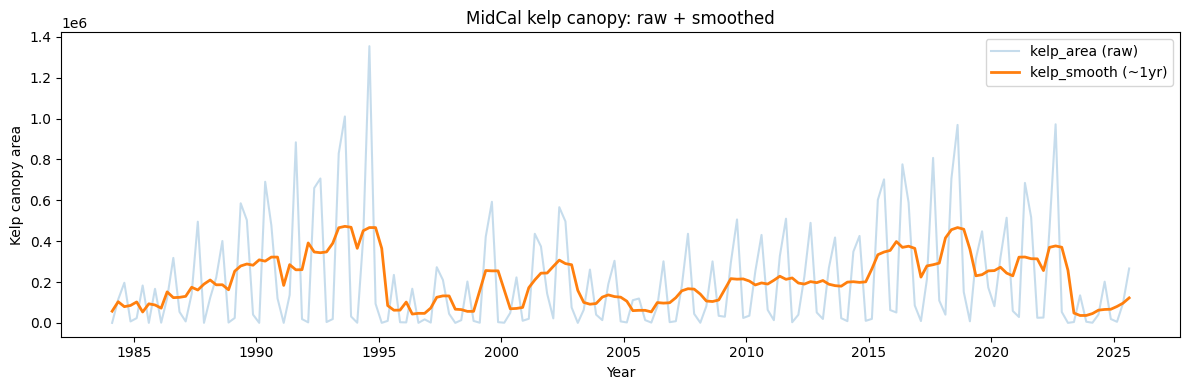

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

fp = "../../1_DATA/processed/midcal/kelp_timeseries_midcal_bbox.csv"

df = pd.read_csv(fp)
df[df.columns[0]] = pd.to_datetime(df[df.columns[0]])
df = df.set_index(df.columns[0]).sort_index()

plt.figure(figsize=(12,4))
plt.plot(df.index, df["kelp_area"], alpha=0.25, label="kelp_area (raw)")
plt.plot(df.index, df["kelp_smooth"], linewidth=2, label="kelp_smooth (~1yr)")
plt.title("MidCal kelp canopy: raw + smoothed")
plt.xlabel("Year")
plt.ylabel("Kelp canopy area")
plt.legend()
plt.tight_layout()
plt.show()